# ✈️ Airline Ticket Price Prediction using Machine Learning
**Objective**: Build and evaluate an end-to-end Machine Learning pipeline to predict flight ticket prices in India based on airline, route, journey dates, duration, and stops.

---
### Table of Contents:
1. **Environment Setup & Data Loading**
2. **Exploratory Data Analysis (EDA)**
3. **Data Preprocessing & Feature Engineering**
4. **Model Training & Benchmarking**
5. **Model Evaluation & Residual Analysis**
6. **Feature Importance**
7. **Sample Flight Price Predictions**


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Configure aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
%matplotlib inline


## 1. Data Loading & Inspection

In [2]:
df_raw = pd.read_excel('../dataset/data.xlsx')
print('Dataset Shape:', df_raw.shape)
df_raw.head()



Dataset Shape: (10683, 11)


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [4]:
# Check for missing values
df_raw.isnull().sum()


Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

## 2. Data Preprocessing & Feature Engineering
- Drop the single missing row.
- Drop anomalous flight duration ('5m').
- Extract Journey Day, Month, Weekday from Date_of_Journey.
- Extract Departure Hour and Minute from Dep_Time.
- Extract Arrival Hour and Minute from Arrival_Time.
- Convert Duration into total minutes.
- Map Total_Stops to numeric values.


In [5]:
df = df_raw.copy()
df.dropna(inplace=True)
df = df[df['Duration'] != '5m']

# 1. Date of Journey
df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'], format='%d/%m/%Y')
df['Journey_day'] = df['Date_of_Journey'].dt.day
df['Journey_month'] = df['Date_of_Journey'].dt.month
df['Journey_weekday'] = df['Date_of_Journey'].dt.dayofweek

# 2. Departure Time
df['Dep_hour'] = pd.to_datetime(df['Dep_Time'], format='%H:%M').dt.hour
df['Dep_min'] = pd.to_datetime(df['Dep_Time'], format='%H:%M').dt.minute

# 3. Arrival Time
df['Arrival_hour'] = pd.to_datetime(df['Arrival_Time'].str.split(' ').str[0], format='%H:%M').dt.hour
df['Arrival_min'] = pd.to_datetime(df['Arrival_Time'].str.split(' ').str[0], format='%H:%M').dt.minute

# 4. Duration in Minutes
def parse_duration(d):
    h, m = 0, 0
    parts = d.strip().split()
    for part in parts:
        if 'h' in part:
            h = int(part.replace('h', ''))
        elif 'm' in part:
            m = int(part.replace('m', ''))
    return h * 60 + m

df['Duration_mins'] = df['Duration'].apply(parse_duration)

# 5. Total Stops
stops_map = {'non-stop': 0, '1 stop': 1, '2 stops': 2, '3 stops': 3, '4 stops': 4}
df['Total_Stops'] = df['Total_Stops'].map(stops_map)

# 6. Clean Additional Info
df['Additional_Info'] = df['Additional_Info'].replace({'No Info': 'No info'})

df.head()


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Journey_weekday,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_mins
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,0,No info,3897,24,3,6,22,20,1,10,170
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2,No info,7662,1,5,2,5,50,13,15,445
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2,No info,13882,9,6,6,9,25,4,25,1140
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1,No info,6218,12,5,6,18,5,23,30,325
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1,No info,13302,1,3,4,16,50,21,35,285


## 3. Exploratory Data Analysis (EDA)

C:\Users\dell\AppData\Local\Temp\ipykernel_7964\2861739904.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Price', y='Airline', ax=axes[1], palette='Blues_r', orient='h')


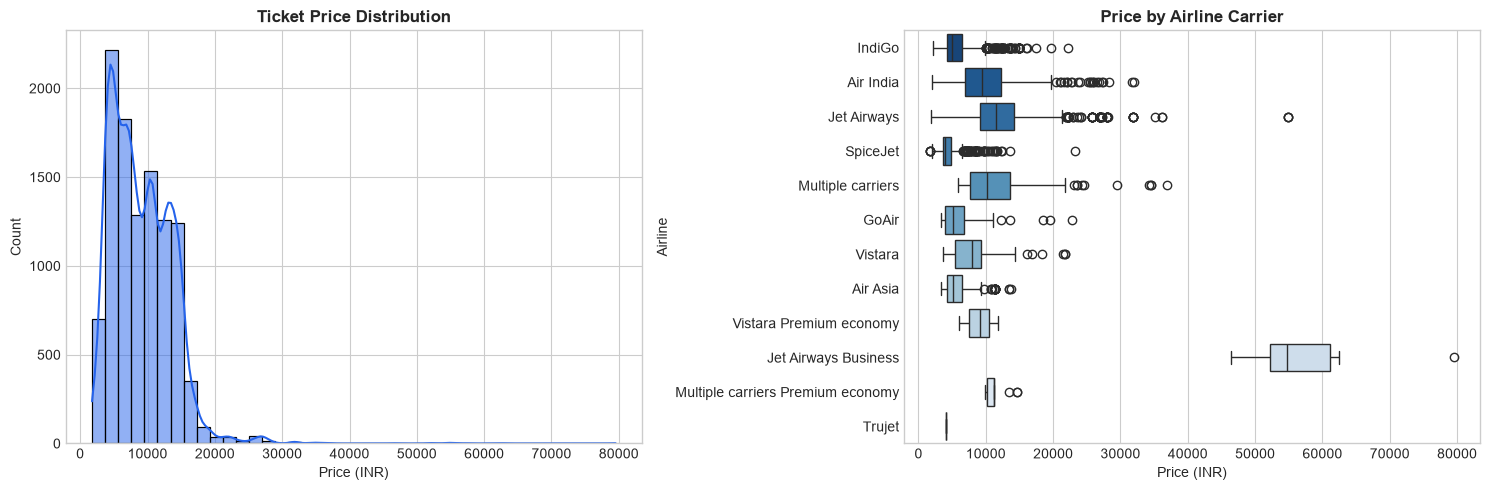

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Price distribution
sns.histplot(df['Price'], bins=40, kde=True, ax=axes[0], color='#2563eb')
axes[0].set_title('Ticket Price Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Price (INR)')

# Boxplot of Price by Airline
sns.boxplot(data=df, x='Price', y='Airline', ax=axes[1], palette='Blues_r', orient='h')
axes[1].set_title('Price by Airline Carrier', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Price (INR)')

plt.tight_layout()
plt.show()


C:\Users\dell\AppData\Local\Temp\ipykernel_7964\725426894.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Total_Stops', y='Price', ax=axes[0], palette='crest')


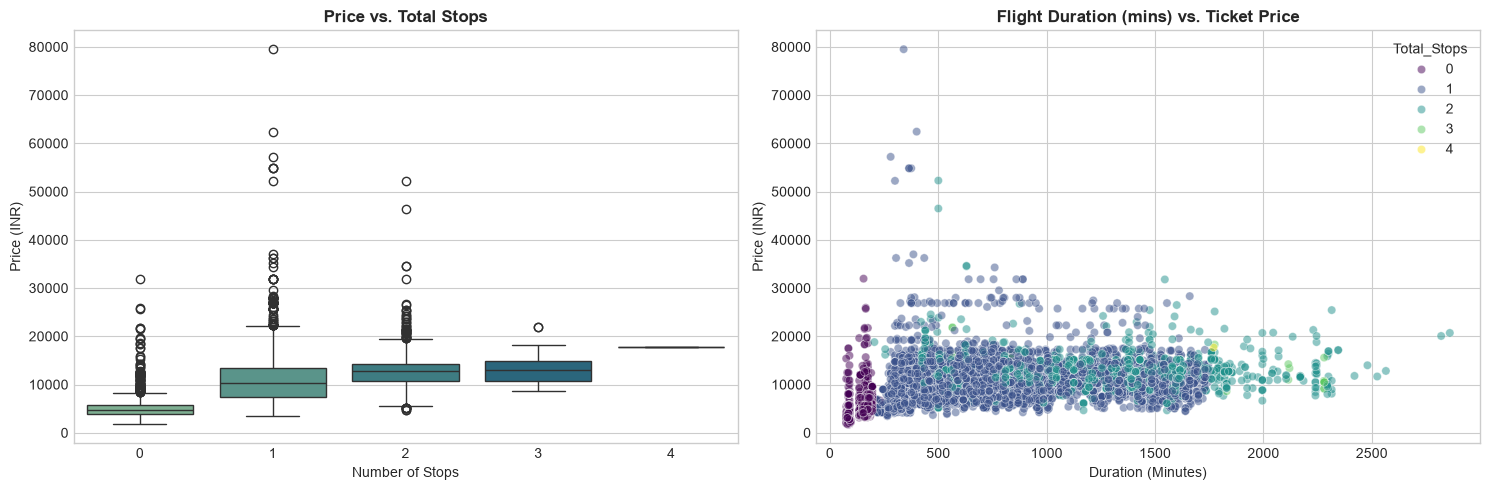

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Total Stops vs Price
sns.boxplot(data=df, x='Total_Stops', y='Price', ax=axes[0], palette='crest')
axes[0].set_title('Price vs. Total Stops', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Stops')
axes[0].set_ylabel('Price (INR)')

# Duration vs Price
sns.scatterplot(data=df, x='Duration_mins', y='Price', hue='Total_Stops', alpha=0.5, palette='viridis', ax=axes[1])
axes[1].set_title('Flight Duration (mins) vs. Ticket Price', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Duration (Minutes)')
axes[1].set_ylabel('Price (INR)')

plt.tight_layout()
plt.show()


## 4. Model Training & Benchmarking

In [8]:
cat_cols = ['Airline', 'Source', 'Destination', 'Additional_Info']
num_cols = ['Total_Stops', 'Journey_day', 'Journey_month', 'Journey_weekday', 
            'Dep_hour', 'Dep_min', 'Arrival_hour', 'Arrival_min', 'Duration_mins']

X = df[cat_cols + num_cols]
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ],
    remainder='passthrough'
)

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'HistGradientBoosting': HistGradientBoostingRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1),
    'Extra Trees': ExtraTreesRegressor(n_estimators=200, random_state=42, n_jobs=-1)
}

benchmark_results = []
trained_pipelines = {}

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    pipe.fit(X_train, y_train)
    trained_pipelines[name] = pipe
    
    preds = pipe.predict(X_test)
    benchmark_results.append({
        'Model': name,
        'R2 Score': r2_score(y_test, preds),
        'MAE (INR)': mean_absolute_error(y_test, preds),
        'RMSE (INR)': np.sqrt(mean_squared_error(y_test, preds)),
        'MAPE (%)': mean_absolute_percentage_error(y_test, preds) * 100
    })

res_df = pd.DataFrame(benchmark_results).sort_values(by='R2 Score', ascending=False)
res_df


,Model,R2 Score,MAE (INR),RMSE (INR),MAPE (%)
4,Extra Trees,0.921518,583.240501,1287.203887,6.757605
3,Random Forest,0.911506,621.233920,1366.848058,7.126215
2,HistGradientBoosting,0.890081,894.966093,1523.348410,10.490886
1,Ridge Regression,0.707239,1736.770023,2486.099315,20.974417
0,Linear Regression,0.703204,1739.758022,2503.176010,20.959114


## 5. Model Evaluation & Residual Diagnostics

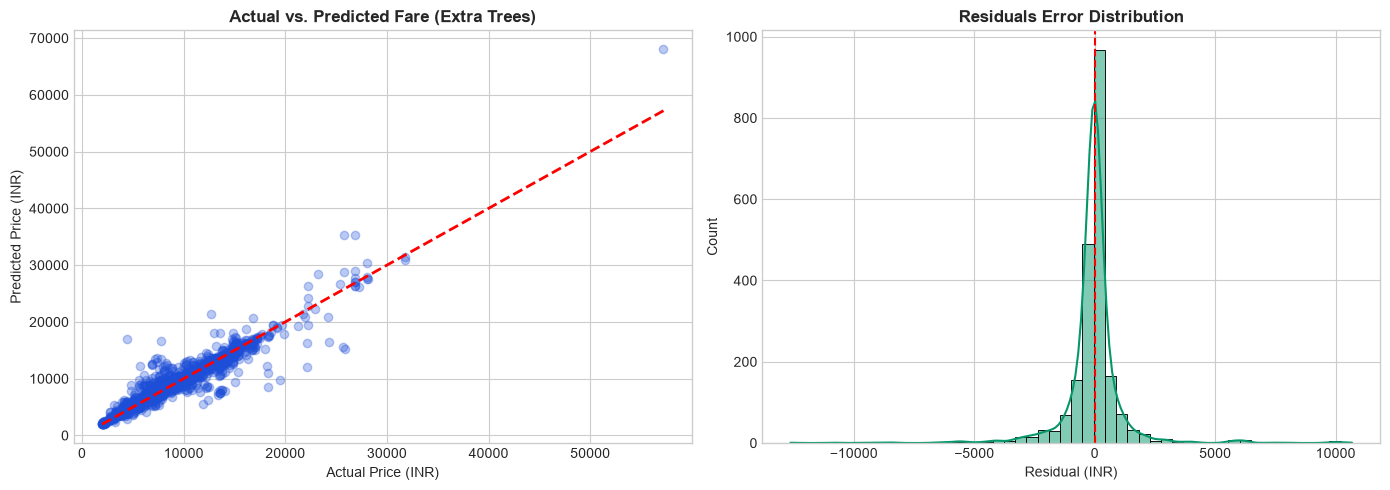

In [9]:
champion_pipe = trained_pipelines['Extra Trees']
best_preds = champion_pipe.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test, best_preds, alpha=0.3, color='#1d4ed8')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Actual vs. Predicted Fare (Extra Trees)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Actual Price (INR)')
axes[0].set_ylabel('Predicted Price (INR)')

# Residuals
residuals = y_test - best_preds
sns.histplot(residuals, bins=50, kde=True, ax=axes[1], color='#059669')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Residuals Error Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Residual (INR)')

plt.tight_layout()
plt.show()


## 6. Live Flight Price Prediction Test

In [10]:
sample_flight = pd.DataFrame([{
    'Airline': 'IndiGo',
    'Source': 'Delhi',
    'Destination': 'Cochin',
    'Additional_Info': 'No info',
    'Total_Stops': 1,
    'Journey_day': 15,
    'Journey_month': 6,
    'Journey_weekday': 0,
    'Dep_hour': 10,
    'Dep_min': 30,
    'Arrival_hour': 14,
    'Arrival_min': 15,
    'Duration_mins': 225
}])

predicted_fare = champion_pipe.predict(sample_flight)[0]
print(f'Estimated Flight Price: INR {predicted_fare:,.2f}')


Estimated Flight Price: INR 5,869.90
